In [2]:
!pip install seaborn matplotlib


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.59.0-cp313-cp313-win_amd64.whl.metadata (110 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.59.0-cp313-cp313-win_amd64.whl (2.2 MB)
Using cached kiwisolver-1.4.8-cp313-cp313-win_amd64.whl (71 kB)
Using cached pillow-11.3.0-cp313-cp313-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------

In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("healthcare-dataset-stroke-data.csv")
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [9]:
data['heart_disease'].value_counts()


heart_disease
0    4834
1     276
Name: count, dtype: int64

In [10]:
data['hypertension'].value_counts()


hypertension
0    4612
1     498
Name: count, dtype: int64

In [11]:
data['gender'].value_counts()


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [12]:
data['ever_married'].value_counts()


ever_married
Yes    3353
No     1757
Name: count, dtype: int64

In [13]:
data['work_type'].value_counts()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [14]:
data['Residence_type'].value_counts()

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

In [15]:
data['smoking_status'].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [16]:
data = data[data['gender'].isin(['Female','Male'])]
data['gender'].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

In [17]:
bmi_mean = data['bmi'].mean()

data['bmi']= data['bmi'].apply(lambda x: bmi_mean if pd.isnull(x) else x)
data.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'avg_glucose_level'}>],
       [<Axes: title={'center': 'bmi'}>, <Axes: >]], dtype=object)

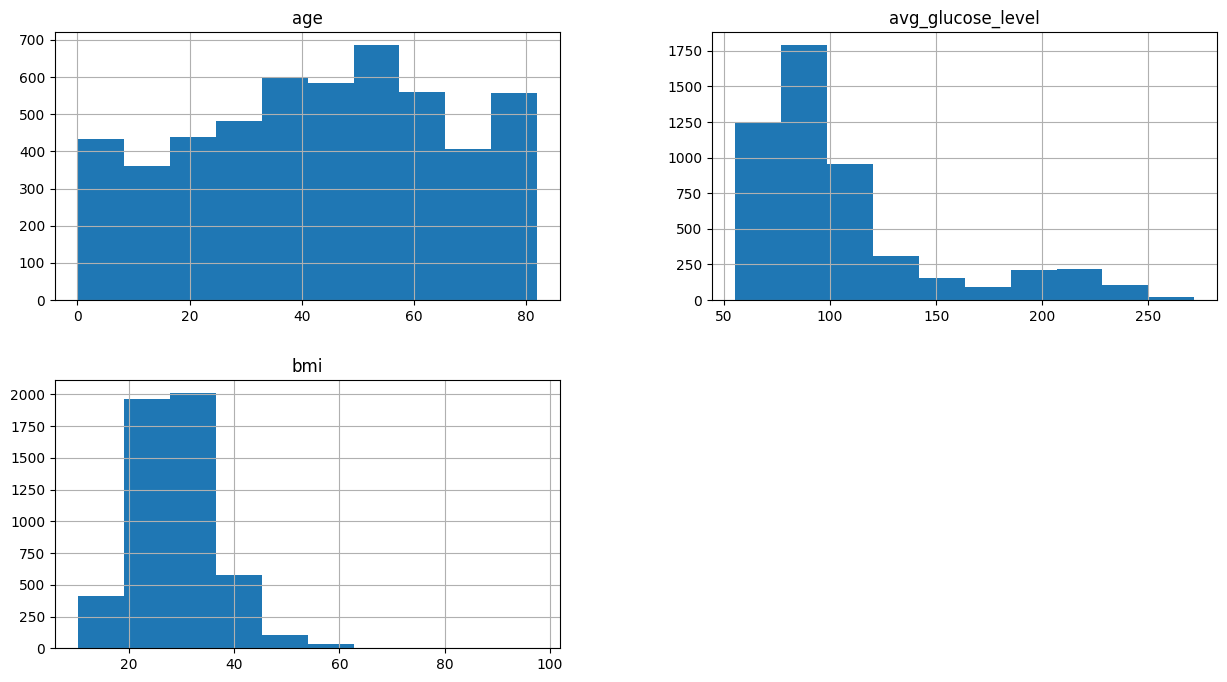

In [19]:
histogram_columns = ['age', 'avg_glucose_level','bmi']
data[histogram_columns].hist(figsize=(15,8))

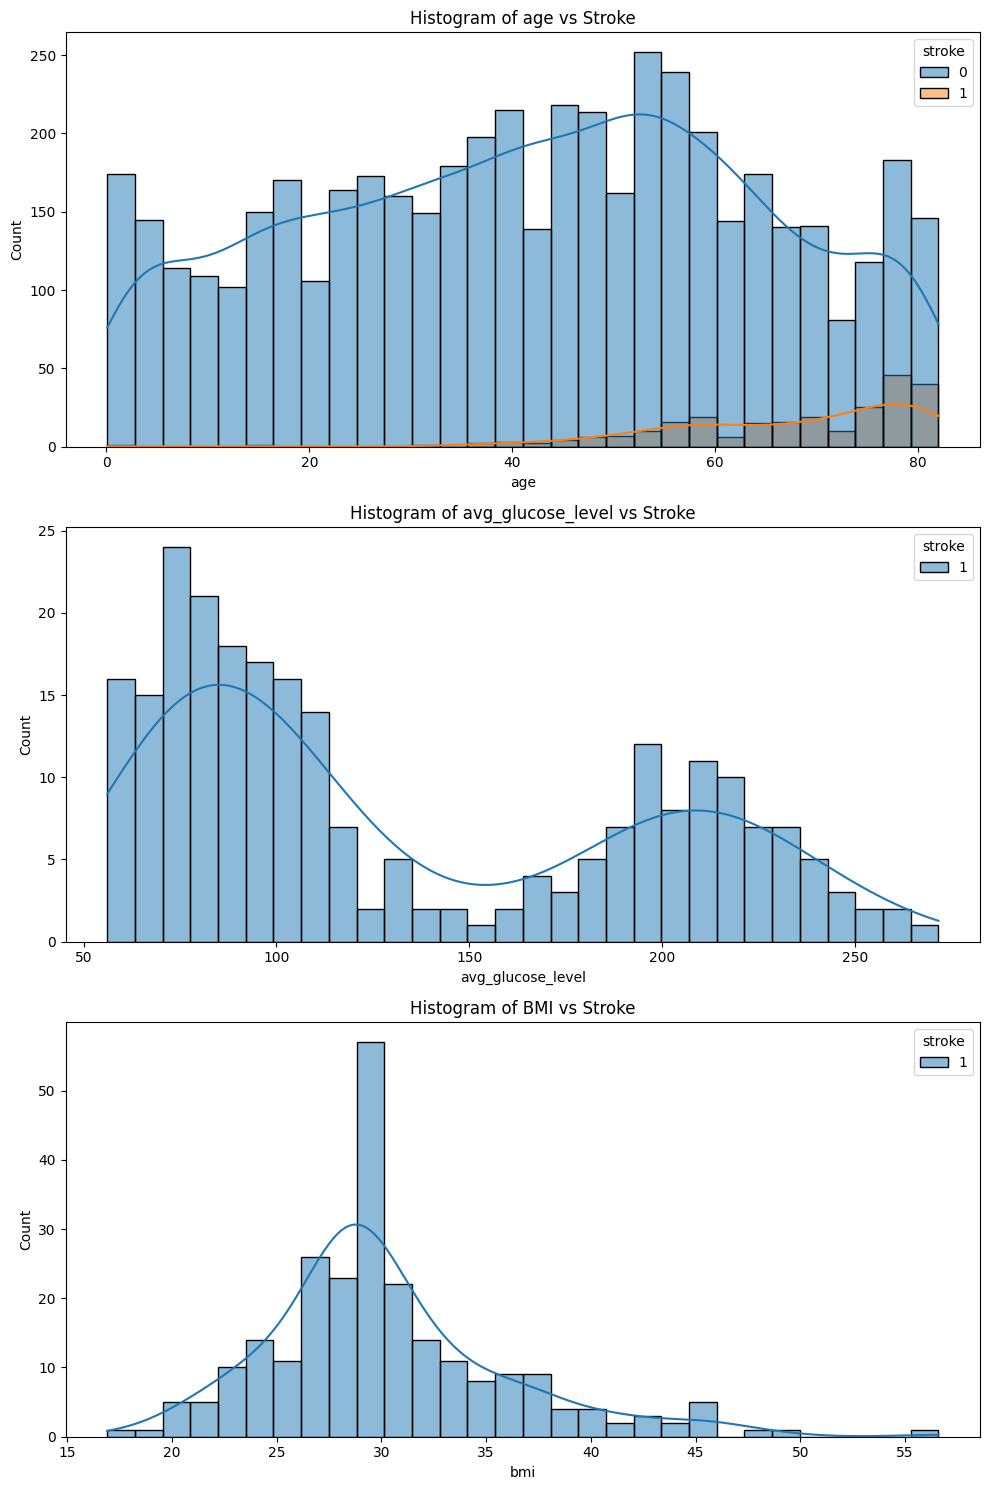

In [22]:
numerical_columns = ['age','avg_glucose_level', 'bmi']
fig , (ax1,ax2,ax3) = plt.subplots(nrows = 3, ncols=1, figsize=(10,15))
sns.histplot(x='age',hue='stroke',data=data,kde=True,ax=ax1,bins=30)
ax1.set_title('Histogram of age vs Stroke')
ax1.set_xlabel('age')
ax2.set_ylabel('Count')

stroke_positive = data[data['stroke']==1]
sns.histplot(x='avg_glucose_level',data=stroke_positive,hue='stroke',kde=True, ax=ax2, bins=30)
ax2.set_title('Histogram of avg_glucose_level vs Stroke')
ax2.set_xlabel('avg_glucose_level')
ax2.set_ylabel('Count')

sns.histplot(x='bmi', hue='stroke', data=stroke_positive, bins=30,ax=ax3,kde=True)
ax3.set_title('Histogram of BMI vs Stroke')
ax3.set_xlabel('bmi')
ax3.set_ylabel('Count')

plt.tight_layout()
plt.show()

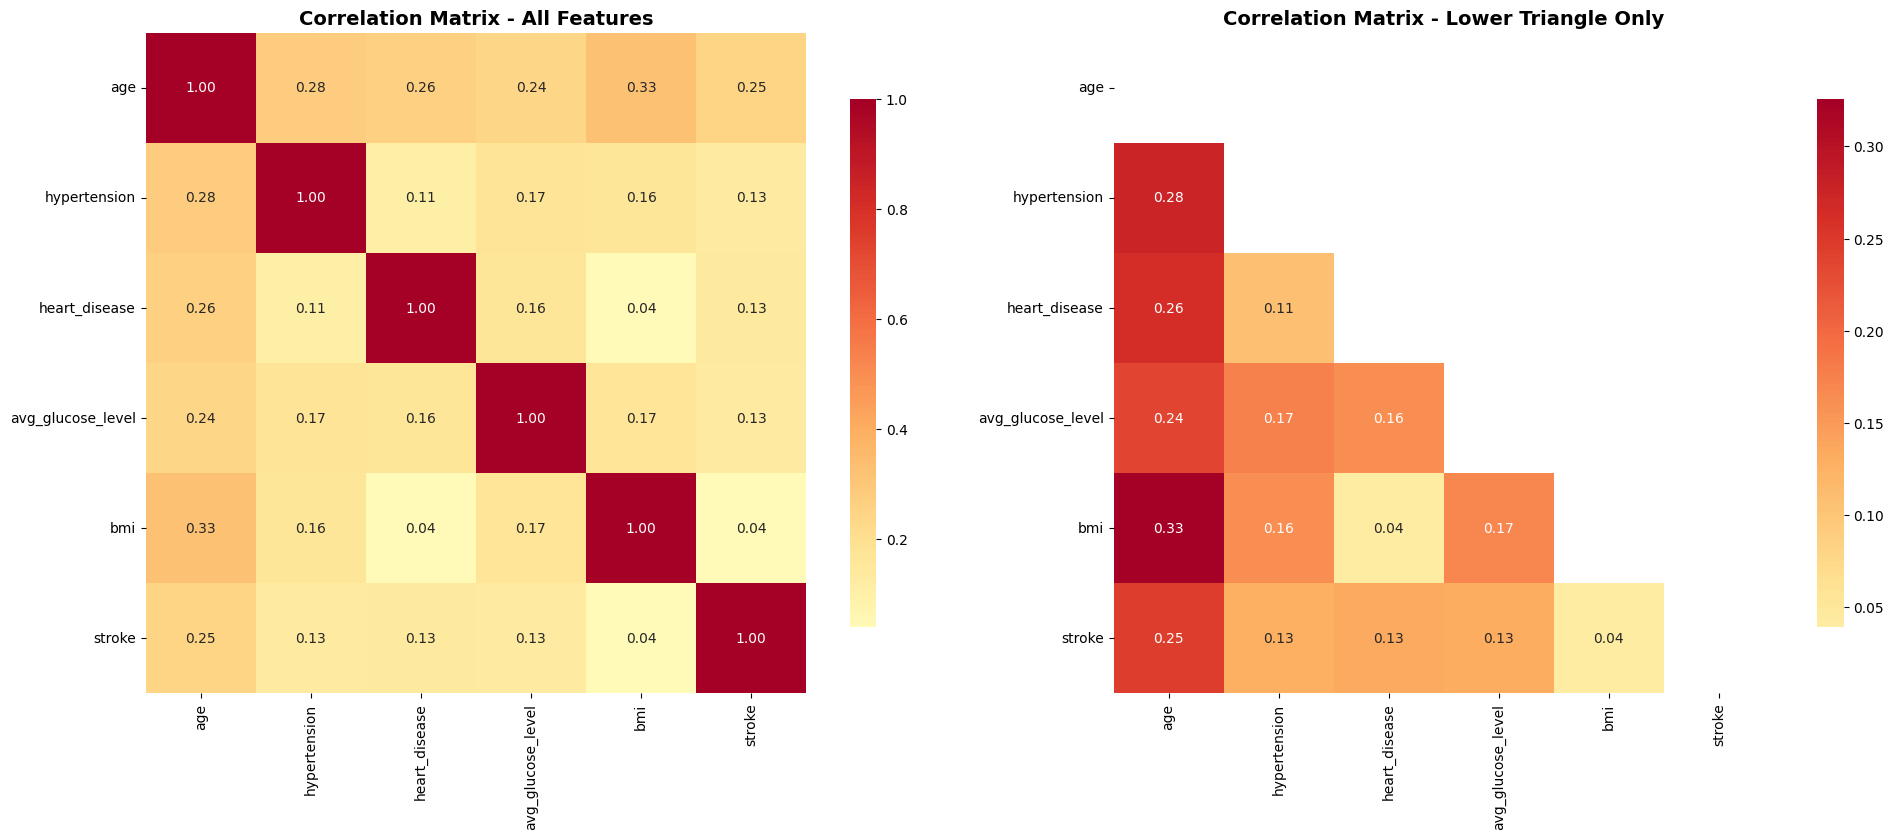

In [30]:
numerical_features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

corr_matrix = data[numerical_features].corr()
    
    # Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Basic heatmap
sns.heatmap(corr_matrix, 
                annot=True,           # Show correlation values
                cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
                center=0,             # Center colormap at 0
                square=True,          # Square cells
                fmt='.2f',            # Format to 2 decimal places
                cbar_kws={'shrink': 0.8},
                ax=axes[0])
axes[0].set_title('Correlation Matrix - All Features', fontsize=14, fontweight='bold')
    
    # Plot 2: Enhanced heatmap with mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
                mask=mask,            # Hide upper triangle (avoid duplication)
                annot=True, 
                cmap='RdYlBu_r', 
                center=0,
                square=True, 
                fmt='.2f',
                cbar_kws={'shrink': 0.8},
                ax=axes[1])
axes[1].set_title('Correlation Matrix - Lower Triangle Only', fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.show()